In [29]:
# Importing the Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import pyplot
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler,LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from scipy.stats import pearsonr
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor, StackingRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from prettytable import PrettyTable

In [31]:
# load the dataset
data = pd.read_excel('BBDM Project for 2nd research article.xlsx')

# Columns to exclude
columns_to_exclude = ['Chainage','Formation','RMC']

# Prepare Features and Target
X = data.drop(['PRnet'] + columns_to_exclude, axis=1)
Y = data['PRnet']

# Label encoding for multiple columns
label_encoder = LabelEncoder()
for col in ['Lithology', 'Weathering', 'Rock Strength']:
    X[col] = label_encoder.fit_transform(X[col])

In [33]:
# Split the data into training, validation, and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Data Standardization
scaler = RobustScaler()
scaler.fit(X_train)  # Fit on the training data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [35]:
# Define the base models
def get_base_models():
    models = dict()
    models['SVR'] = SVR(C=50.0, gamma='scale', kernel='rbf')
    models['DT'] = DecisionTreeRegressor(criterion='absolute_error',
                              max_depth=10, min_samples_leaf=6, min_samples_split=2, 
                              splitter='best')
    models['RF'] = RandomForestRegressor(random_state=42, max_depth=30, max_features='log2', 
                                         min_samples_leaf=1, min_samples_split=5, n_estimators=200)
    models['KNN'] = KNeighborsRegressor(n_neighbors=5, p=1, weights='distance',algorithm= 'auto')
    models['XGBoost'] = XGBRegressor(colsample_bytree=1, gamma=5, learning_rate=0.1, max_depth=7, 
                                     n_estimators=100, subsample=0.8)
    models['Bagging'] = BaggingRegressor(bootstrap=True, bootstrap_features=False, max_features=1.0,
                                         max_samples=0.5, n_estimators=100)
    return models

# Define the meta-model with optimized hyperparameters
meta_regressor = RandomForestRegressor(random_state=42, max_depth=30, 
                                       max_features='sqrt', min_samples_leaf=1,
                                       min_samples_split=5, n_estimators=200)

# Combine base models and meta model
base_models = get_base_models()

# Define the stacking regressor with SVR as the meta-regressor
stacking_regressor = StackingRegressor(estimators=list(base_models.items()), final_estimator=meta_regressor)

# Train the stacking regressor
stacking_regressor.fit(X_train_scaled, Y_train)

# Predict on the training data
Y_train_pred = stacking_regressor.predict(X_train_scaled)

# Train metrics
r2_train = r2_score(Y_train, Y_train_pred)
mae_train = mean_absolute_error(Y_train, Y_train_pred)
mse_train = mean_squared_error(Y_train, Y_train_pred)
rmse_train = np.sqrt(mse_train)
mape_train = np.mean(np.abs((Y_train - Y_train_pred) / Y_train)) * 100


# Predict on the test data
Y_test_pred = stacking_regressor.predict(X_test_scaled)

# Test metrics (already in your code, but grouped here for clarity)
r2_test = r2_score(Y_test, Y_test_pred)
mae_test = mean_absolute_error(Y_test, Y_test_pred)
mse_test = mean_squared_error(Y_test, Y_test_pred)
rmse_test = np.sqrt(mse_test)
mape_test = np.mean(np.abs((Y_test - Y_test_pred) / Y_test)) * 100


# Combine both into a DataFrame
metrics_df = pd.DataFrame({
    'Metric': ['R2', 'MAE',  'RMSE', 'MAPE'],
    'Train': [r2_train, mae_train,  rmse_train, mape_train],
    'Test': [r2_test, mae_test,  rmse_test, mape_test]
})

# Round to 3 decimal places
metrics_df[['Train', 'Test']] = metrics_df[['Train', 'Test']].round(3)

# Display the comparison
print(metrics_df)

  Metric  Train   Test
0     R2  0.976  0.937
1    MAE  1.430  2.307
2   RMSE  2.392  3.949
3   MAPE  2.162  3.558


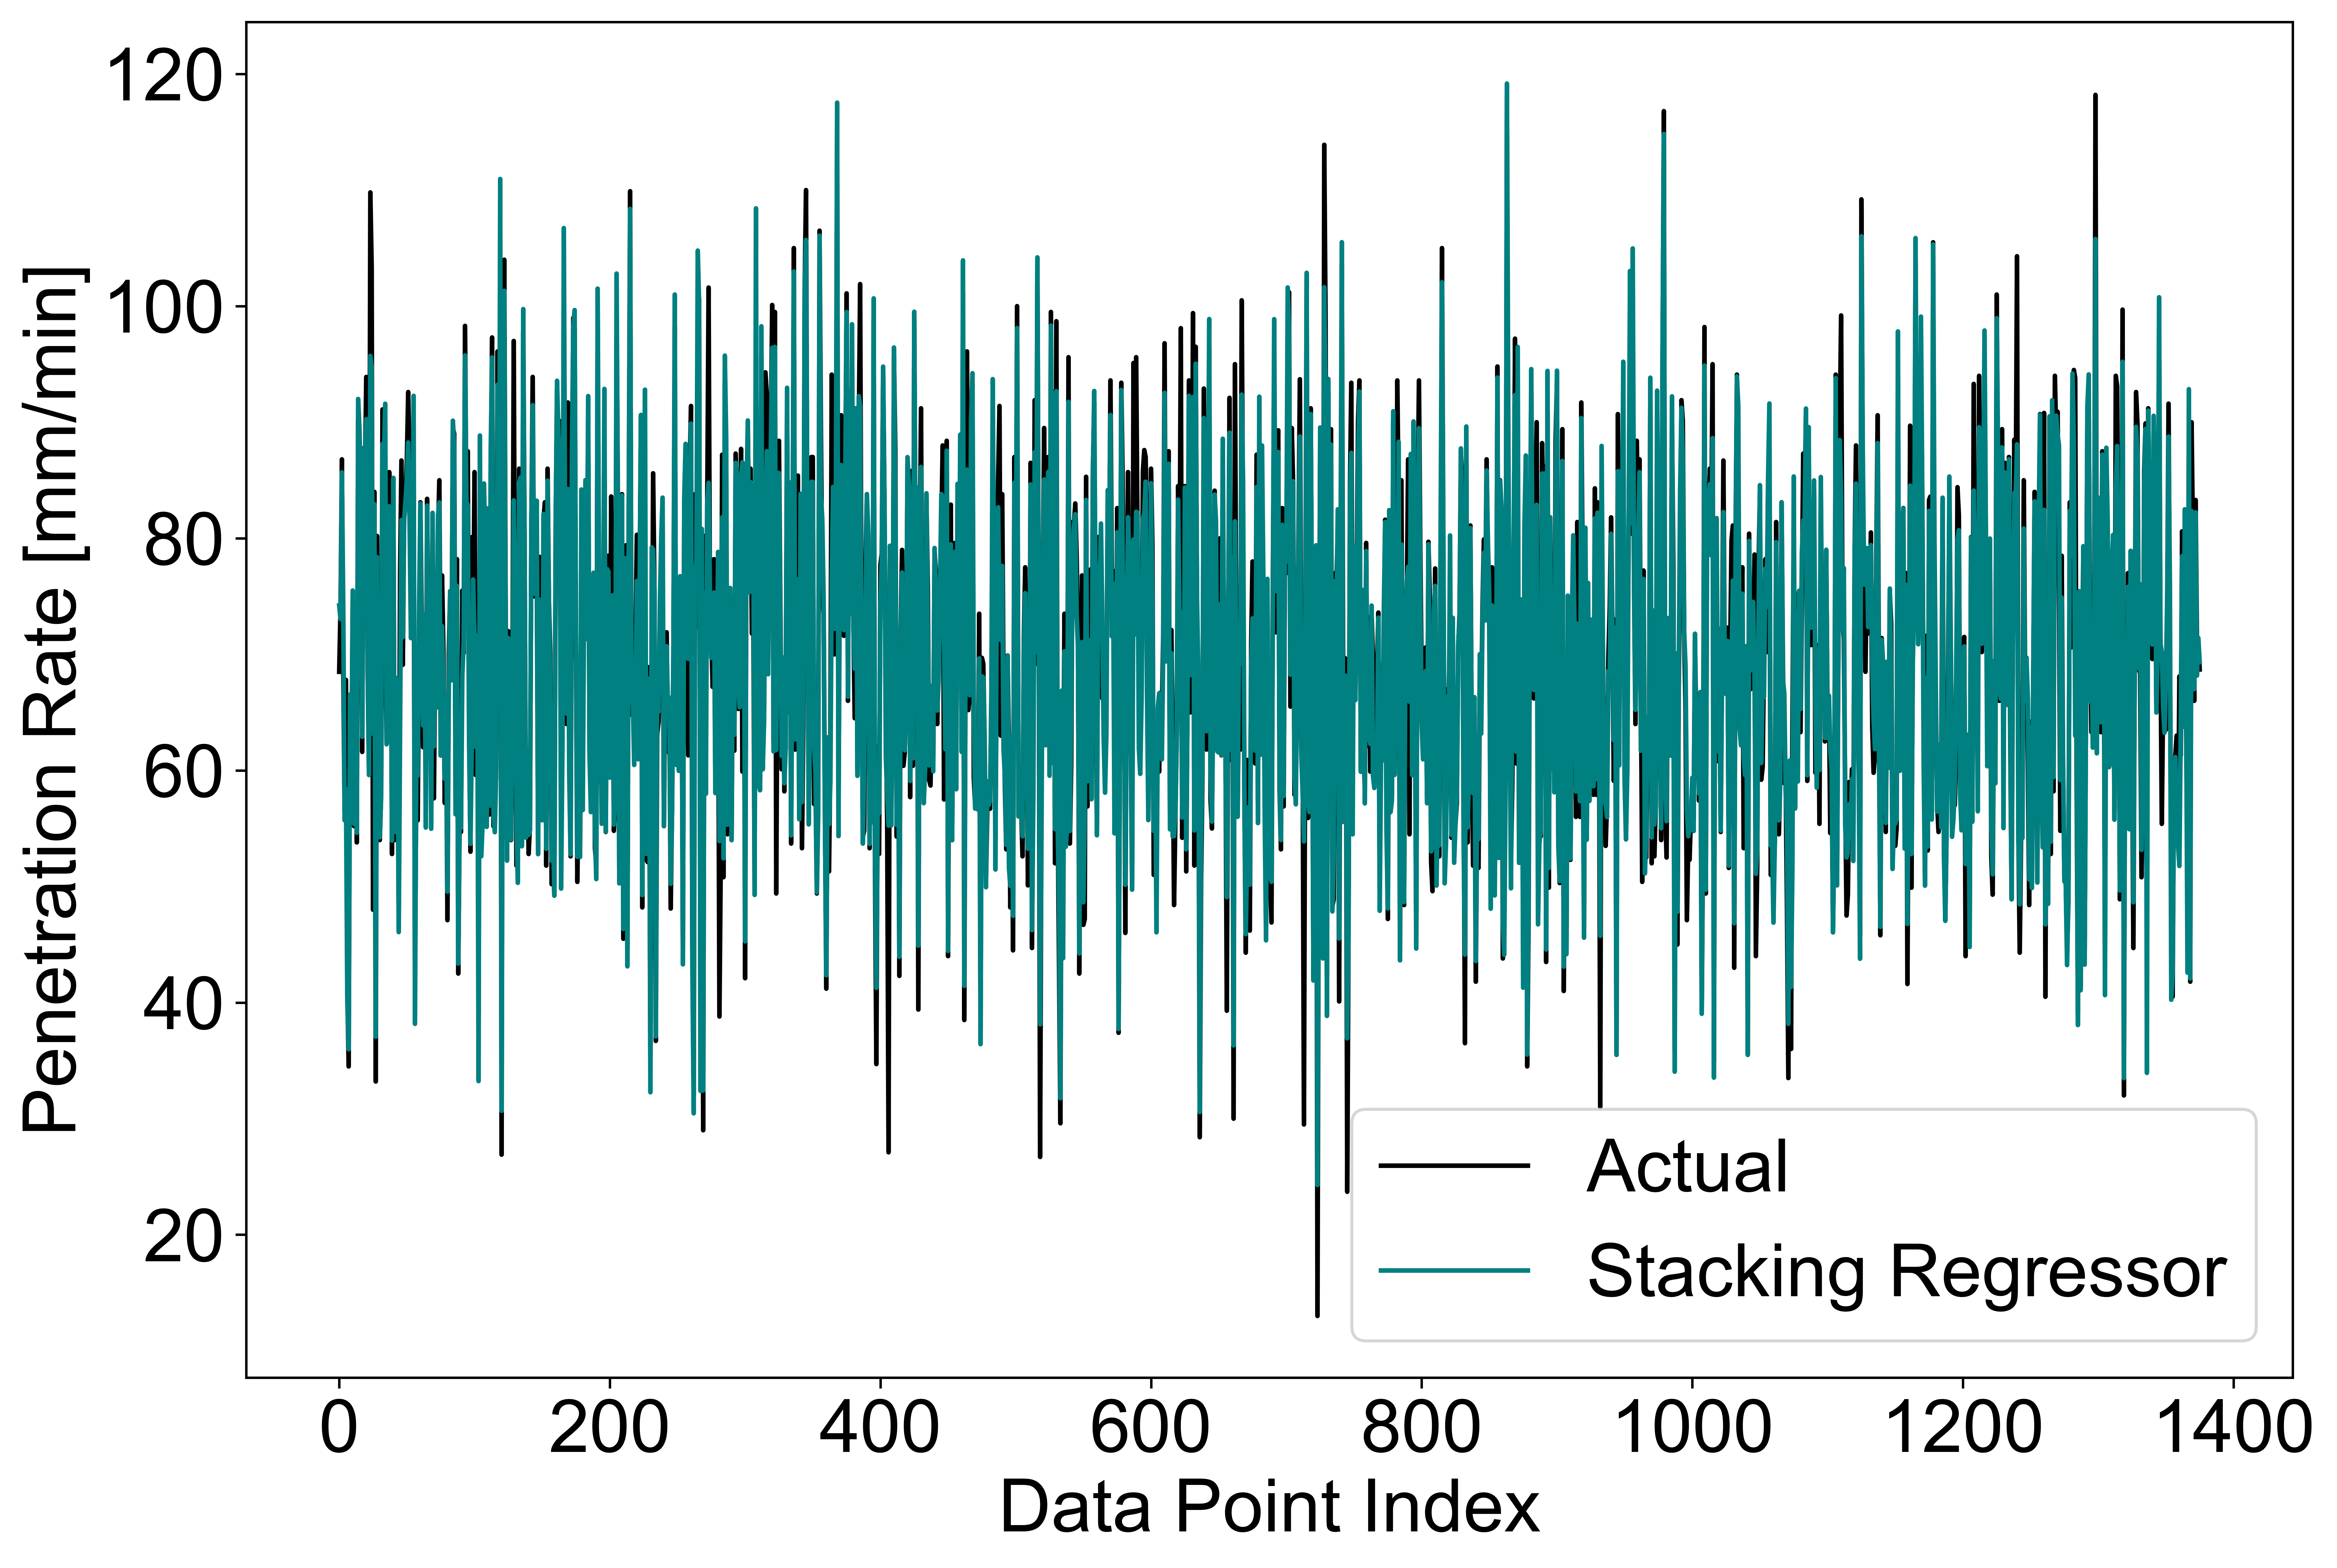

In [5]:
# Create a list of data point indices (numbers) for the entire dataset
data_indices = range(len(Y_test))

# Create a line plot of actual vs. predicted Y values for the entire dataset
pyplot.rc('font', family='Arial')
plt.figure(figsize=(12, 8), dpi=800)
plt.plot(data_indices, Y_test, 'black', label='Actual')
plt.plot(data_indices, Y_test_pred, 'teal', label='Stacking Regressor')
plt.xlabel('Data Point Index', fontsize=24)
plt.ylabel('Penetration Rate [mm/min]', fontsize=24)
#plt.title('Actual vs. Predicted Compressive strength by RF Model', fontsize=24)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)
plt.legend(loc='best', fontsize=24)
plt.show()

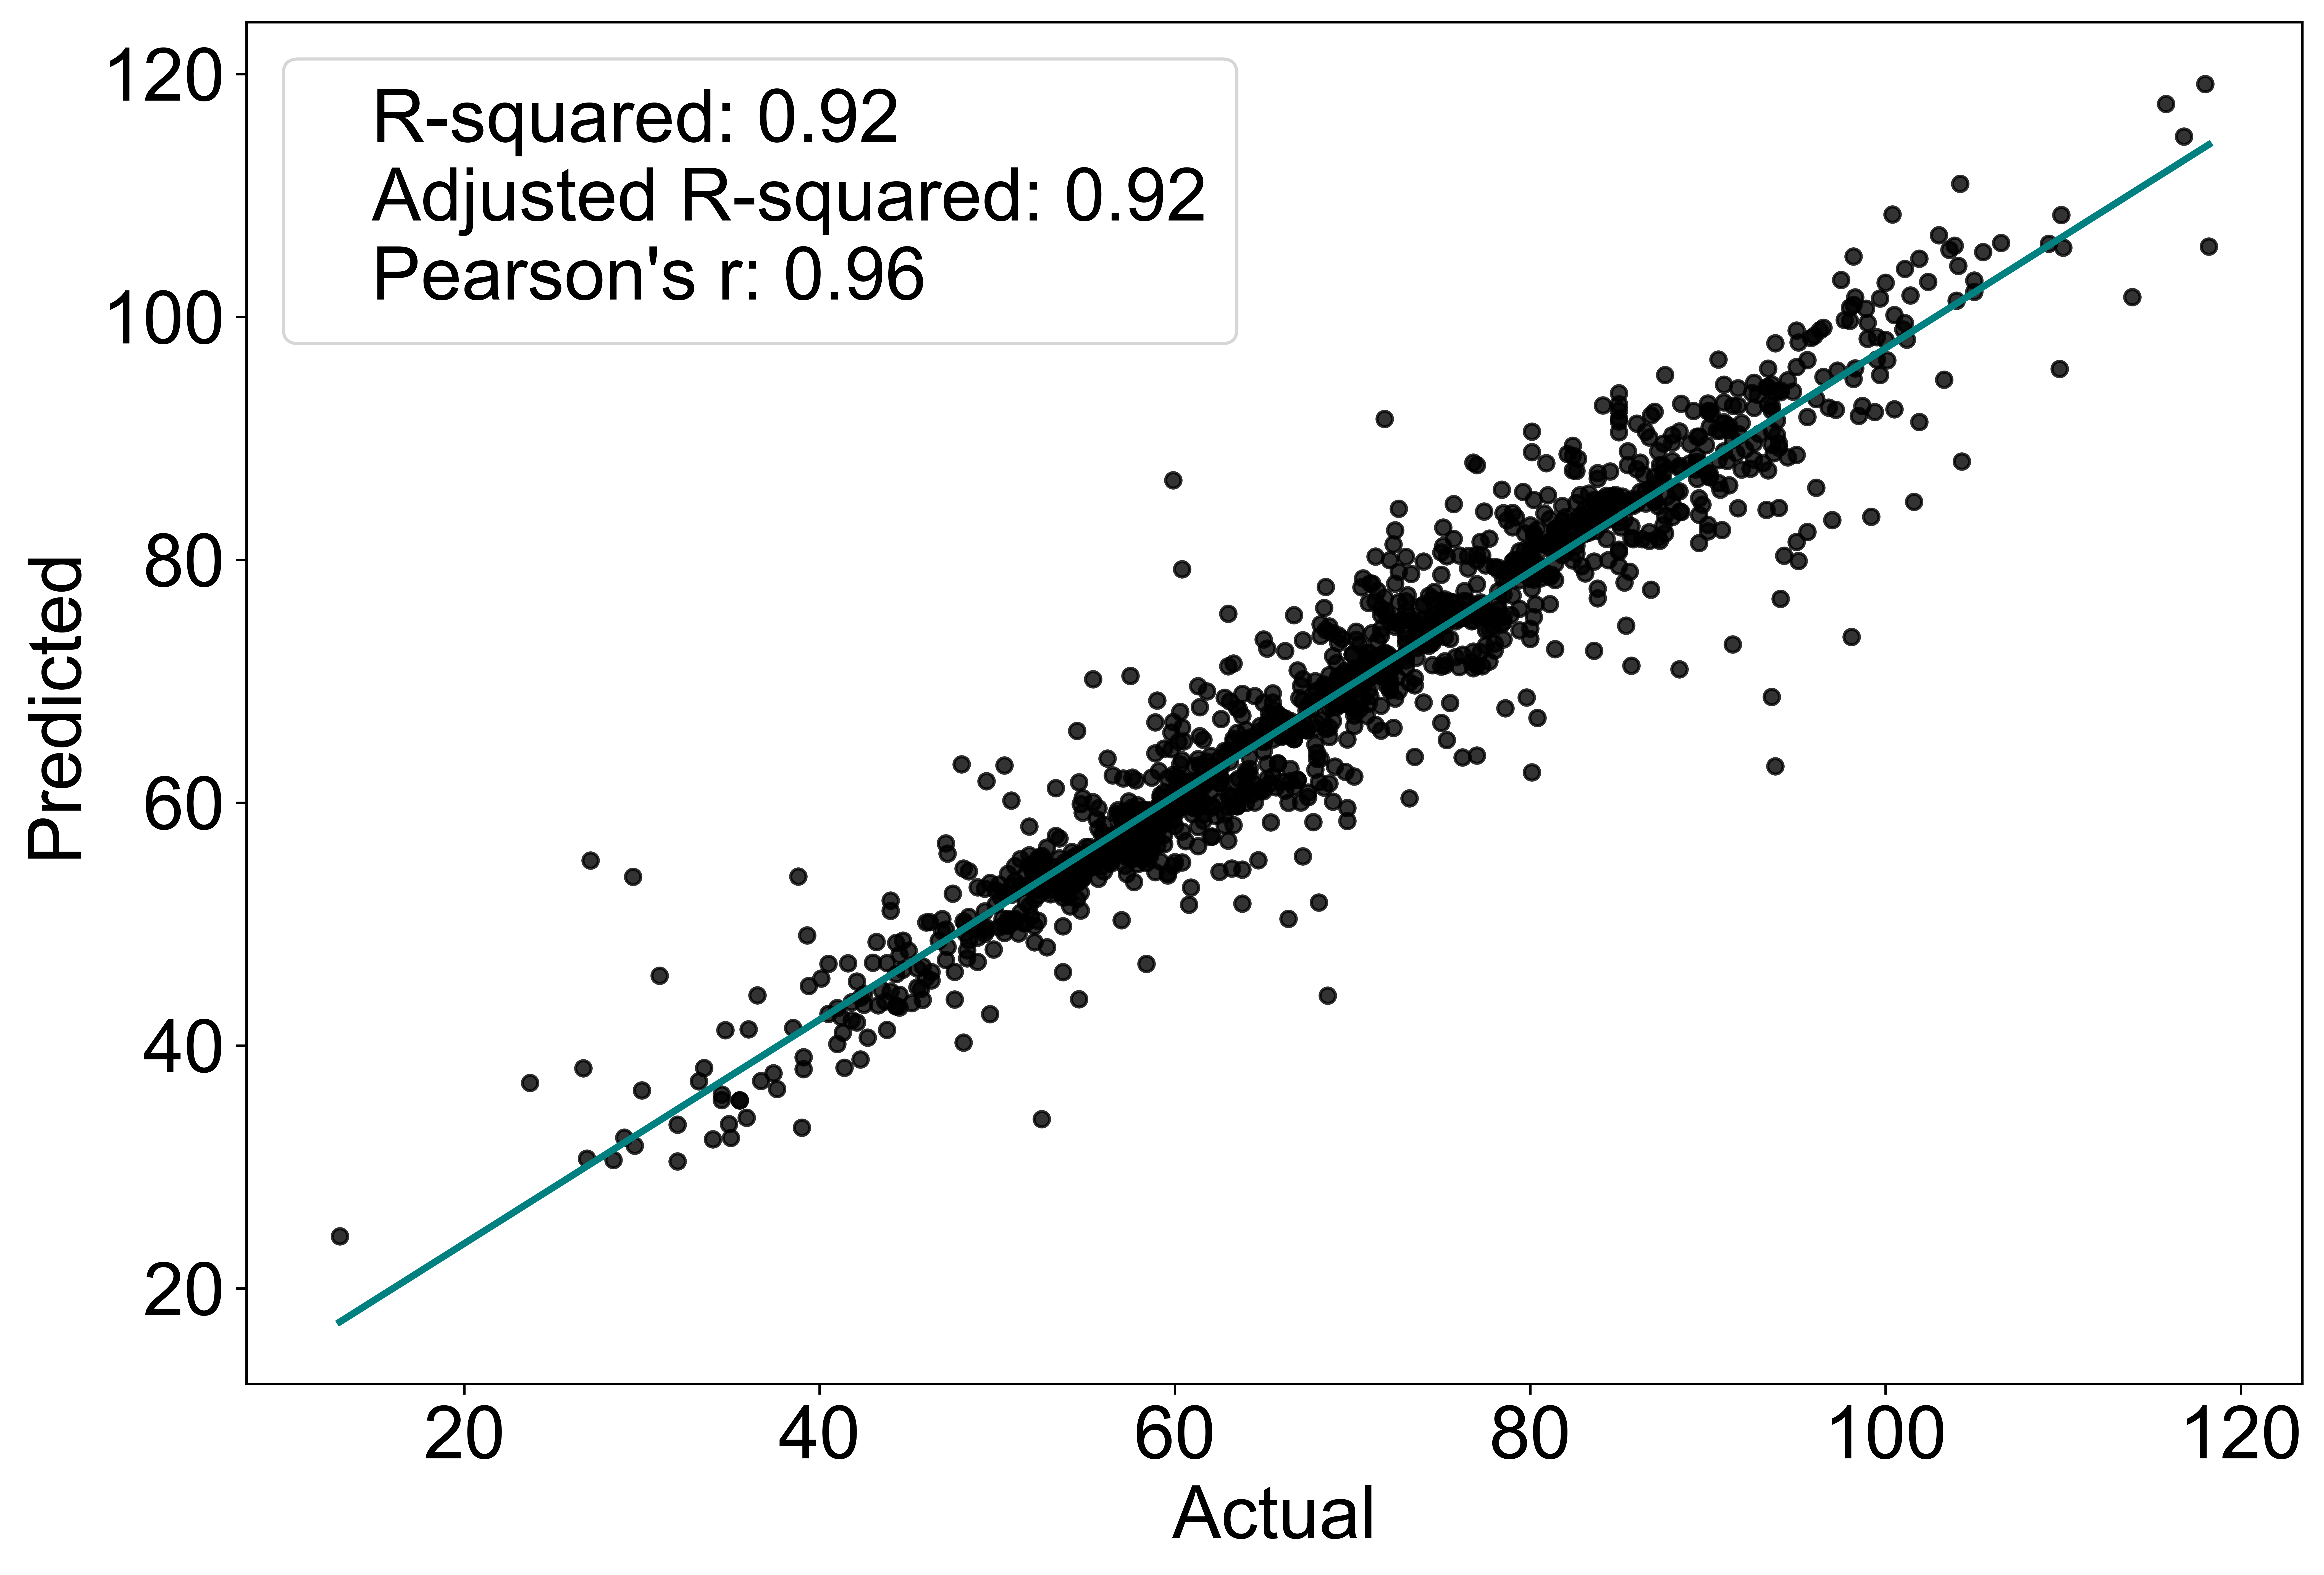

In [6]:
# Calculate additional evaluation metrics
correlation, _ = pearsonr(Y_test, Y_test_pred)
adjusted_r2 = 1 - (1 - r2) * ((len(Y_test) - 1) / (len(Y_test) - X.shape[1] - 1))

# Create a scatter plot with a linear regression line
pyplot.rc('font', family='Arial')
plt.figure(figsize=(12, 8), dpi=800)
sns.regplot(x=Y_test, y=Y_test_pred, ci=None,
            scatter_kws={'s': 25, 'color': 'black'}, line_kws={'color': 'teal'})
plt.xlabel('Actual', fontsize=24)
plt.ylabel('Predicted', fontsize=24)
#plt.title('Scatter Plot with Linear Regression Line of RF model', fontsize=20)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)

# Add R-squared, adjusted R-squared, and Pearson's r to the upper-left corner of the plot
legend_text = f'R-squared: {r2:.2f}\nAdjusted R-squared: {adjusted_r2:.2f}\nPearson\'s r: {correlation:.2f}'
plt.legend([legend_text], loc='upper left', fontsize=24, handlelength=0, markerscale=0)

plt.show()